<a href="https://colab.research.google.com/github/GovardhanReddy731/SkinDiseaseClassifier/blob/main/Skin_allergy_detection_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Using device: cuda


<ipython-input-1-1620b71a13df>:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth
100%|██████████| 74.5M/74.5M [00:00<00:00, 92.1MB/s]
<ipython-input-1-1620b71a13df>:132: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/50, Loss: 198.1192
Validation Accuracy: 17.68%
✅ Saved best model.
Epoch 2/50, Loss: 196.4603
Validation Accuracy: 43.65%
✅ Saved best model.
Epoch 3/50, Loss: 192.8410
Validation Accuracy: 65.75%
✅ Saved best model.
Epoch 4/50, Loss: 179.3457
Validation Accuracy: 62.98%
Epoch 5/50, Loss: 156.1186
Validation Accuracy: 76.80%
✅ Saved best model.
Epoch 6/50, Loss: 136.3008
Validation Accuracy: 79.01%
✅ Saved best model.
Epoch 7/50, Loss: 134.5829
Validation Accuracy: 75.69%
Epoch 8/50, Loss: 131.4502
Validation Accuracy: 82.32%
✅ Saved best model.
Epoch 9/50, Loss: 126.2650
Validation Accuracy: 80.66%
Epoch 10/50, Loss: 123.3913
Validation Accuracy: 78.45%
Epoch 11/50, Loss: 122.2148
Validation Accuracy: 83.98%
✅ Saved best model.
Epoch 12/50, Loss: 122.1106
Validation Accuracy: 82.32%
Epoch 13/50, Loss: 119.4370
Validation Accuracy: 81.77%
Epoch 14/50, Loss: 113.5410
Validation Accuracy: 85.08%
✅ Saved best model.
Epoch 15/50, Loss: 114.5089
Validation Accuracy: 86.74%
✅ Saved b

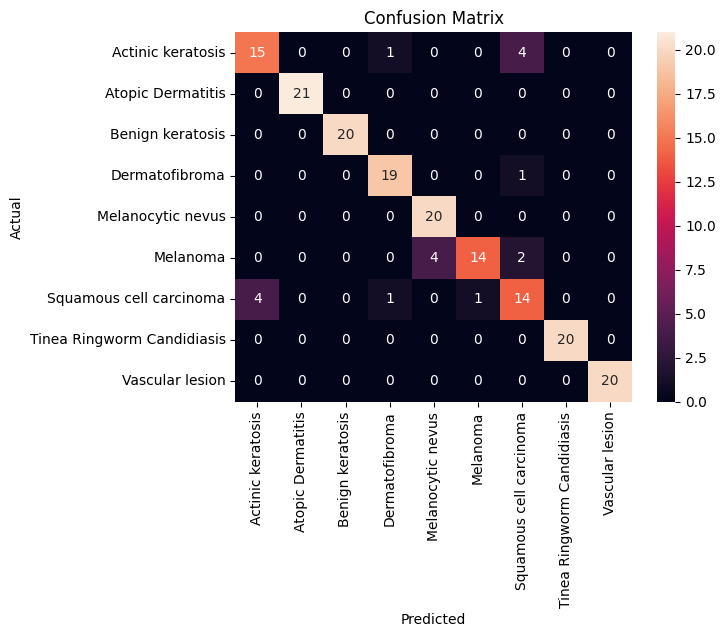

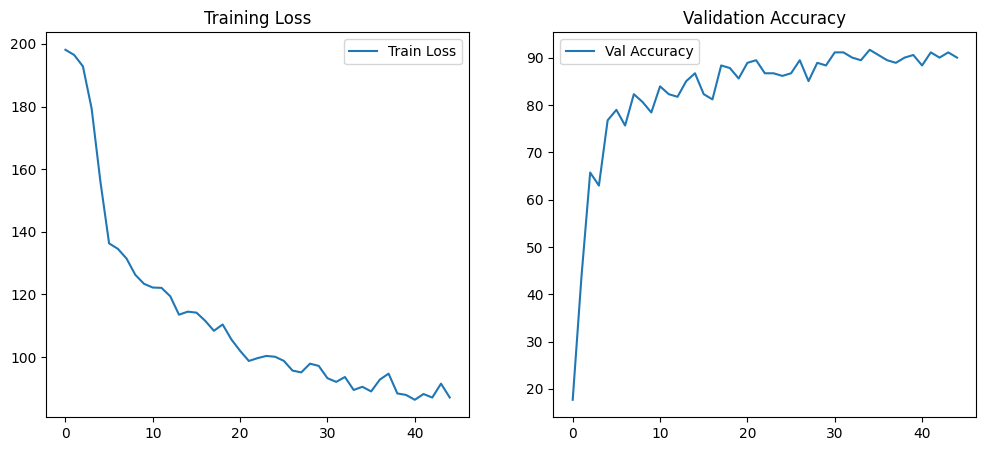

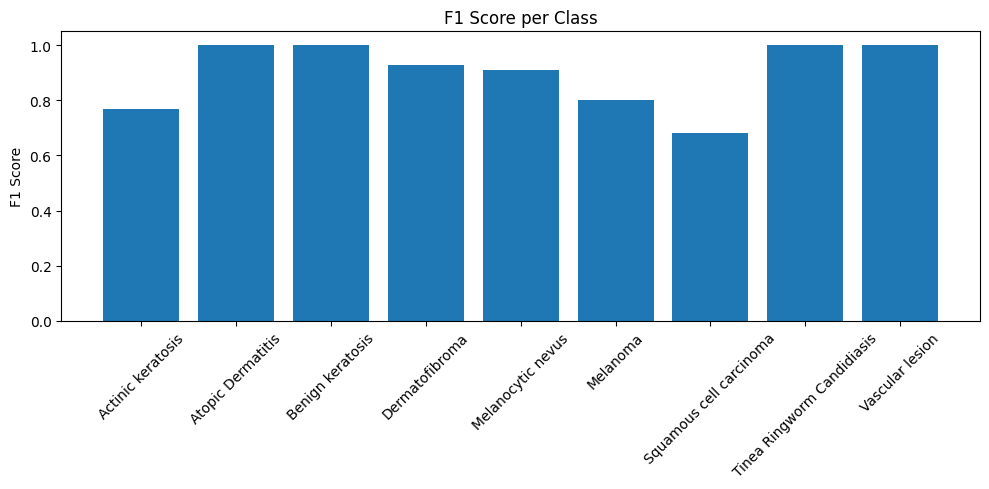

In [ ]:
# Upgraded EfficientNet-B4 Skin Disease Classifier with High Accuracy & Graphs
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# Imports
import os
import gc
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from torch.cuda.amp import GradScaler, autocast

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Paths
train_path = "/content/drive/MyDrive/Ml_Project/archive (2)/Split_smol/train"
val_path = "/content/drive/MyDrive/Ml_Project/archive (2)/Split_smol/val"

# Custom Dataset to skip corrupt images
class CleanImageFolder(datasets.ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform)
        original_len = len(self.samples)
        self.samples = [s for s in self.samples if os.path.exists(s[0])]
        self.targets = [s[1] for s in self.samples]
        removed = original_len - len(self.samples)
        if removed > 0:
            print(f"\u26a0\ufe0f Skipped {removed} missing/corrupt files.")

# Parameters
image_size = 300
batch_size = 8
num_epochs = 50
patience = 10
scaler = GradScaler()

# Transforms
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.2)
])
val_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Datasets and Dataloaders
train_dataset = CleanImageFolder(train_path, transform=train_transform)
val_dataset = CleanImageFolder(val_path, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
num_classes = len(train_dataset.classes)

# Model Setup
weights = EfficientNet_B4_Weights.DEFAULT
model = efficientnet_b4(weights=weights)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(device)

# Class Weights
labels = [label for _, label in train_dataset.samples]
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.0008)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.0008,
                                                steps_per_epoch=len(train_loader), epochs=num_epochs)

# CutMix Functions
def cutmix(images, labels, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    rand_index = torch.randperm(images.size(0)).to(device)
    shuffled_images = images[rand_index]
    shuffled_labels = labels[rand_index]
    bbx1, bby1, bbx2, bby2 = rand_bbox(images.size(), lam)
    images[:, :, bbx1:bbx2, bby1:bby2] = shuffled_images[:, :, bbx1:bbx2, bby1:bby2]
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (images.size(-1) * images.size(-2)))
    return images, labels, shuffled_labels, lam

def rand_bbox(size, lam):
    W, H = size[2], size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    return bbx1, bby1, bbx2, bby2

def cutmix_criterion(pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# Tracking
train_losses, val_accuracies = [], []
best_acc = 0
trigger_times = 0

# Training Loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        images, y_a, y_b, lam = cutmix(images, labels)
        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss = cutmix_criterion(outputs, y_a, y_b, lam)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        running_loss += loss.item()

    train_losses.append(running_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}")

    # Validation
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc = 100 * correct / total
    val_accuracies.append(val_acc)
    print(f"Validation Accuracy: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        trigger_times = 0
        torch.save(model.state_dict(), "best_model_b4_optimized.pth")
        print("\u2705 Saved best model.")
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print("\u23f9\ufe0f Early stopping triggered.")
            break

    gc.collect()
    torch.cuda.empty_cache()

# Final Evaluation
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

print("\nF1 Score:", f1_score(all_labels, all_preds, average='weighted'))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Accuracy & Loss Plots
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.title("Training Loss")
plt.legend()
plt.subplot(1,2,2)
plt.plot(val_accuracies, label='Val Accuracy')
plt.title("Validation Accuracy")
plt.legend()
plt.show()

# F1 Score per Class
report = classification_report(all_labels, all_preds, target_names=train_dataset.classes, output_dict=True)
f1_scores = [report[c]['f1-score'] for c in train_dataset.classes]
plt.figure(figsize=(10,5))
plt.bar(train_dataset.classes, f1_scores)
plt.ylabel('F1 Score')
plt.title('F1 Score per Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
